In [5]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data_with_xylene = pd.read_csv('cleaned_with_xylene.csv')
data_without_xylene = pd.read_csv("cleaned_without_xylene.csv")

print("With Xylene:", data_with_xylene.shape)
print("Without Xylene:", data_without_xylene.shape)

With Xylene: (108035, 13)
Without Xylene: (108035, 12)


In [8]:
X_with = data_with_xylene.drop(columns=['AQI'])
y_with = data_with_xylene['AQI']

X_without = data_without_xylene.drop(columns=['AQI'])
y_without = data_without_xylene['AQI']

In [9]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(X_with, y_with, test_size=0.2, random_state=42)
Xwo_train, Xwo_test, ywo_train, ywo_test = train_test_split(X_without, y_without, test_size=0.2, random_state=42)

In [11]:
# Define Base Models

rf_base = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [12]:
# Hyperparametr Spaces For Random Search

param_dist = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8, 10],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

In [18]:
def train_and_evaluate(X_train, X_test, y_train, y_test, model_label):
    print(f"\nTraining {model_label} ...")
    search = RandomizedSearchCV(
        xgb_base,
        param_distributions=param_dist,
        n_iter=25, cv=3,
        scoring='r2', random_state=42,
        verbose=1, n_jobs=-1
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print(f"Best Parameters for {model_label}:", search.best_params_)

    # Predictions
    y_pred = best_model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{model_label} Results:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Feature Importance Plot
    plt.figure(figsize=(10,6))
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
    sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
    plt.title(f"Top 15 Features - {model_label}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # Save Model + Predictions (Pickle version)
    file_name = f"best_model_{model_label.replace(' ', '_')}.pkl"
    pickle.dump(best_model, open(file_name, "wb"))
    print(f"Model saved as '{file_name}'")

    pred_df = pd.DataFrame({"Actual_AQI": y_test, "Predicted_AQI": y_pred})
    pred_df.to_csv(f"predicted_results_{model_label.replace(' ', '_')}.csv", index=False)
    print(f"Predictions saved for {model_label}")

    return best_model, {
        "Model": model_label,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }


Training Without Xylene ...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters for Without Xylene: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Without Xylene Results:
R² Score: 0.9114
MAE: 18.6287
RMSE: 32.3369


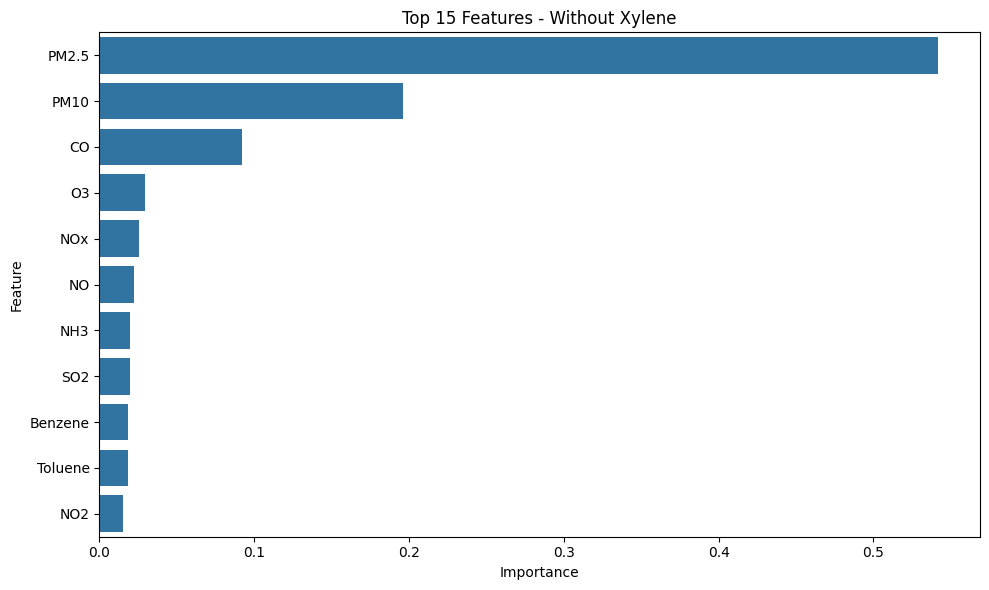

Model saved as 'best_model_Without_Xylene.pkl'
Predictions saved for Without Xylene

Training With Xylene ...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters for With Xylene: {'subsample': 0.7, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

With Xylene Results:
R² Score: 0.9120
MAE: 18.4819
RMSE: 32.2391


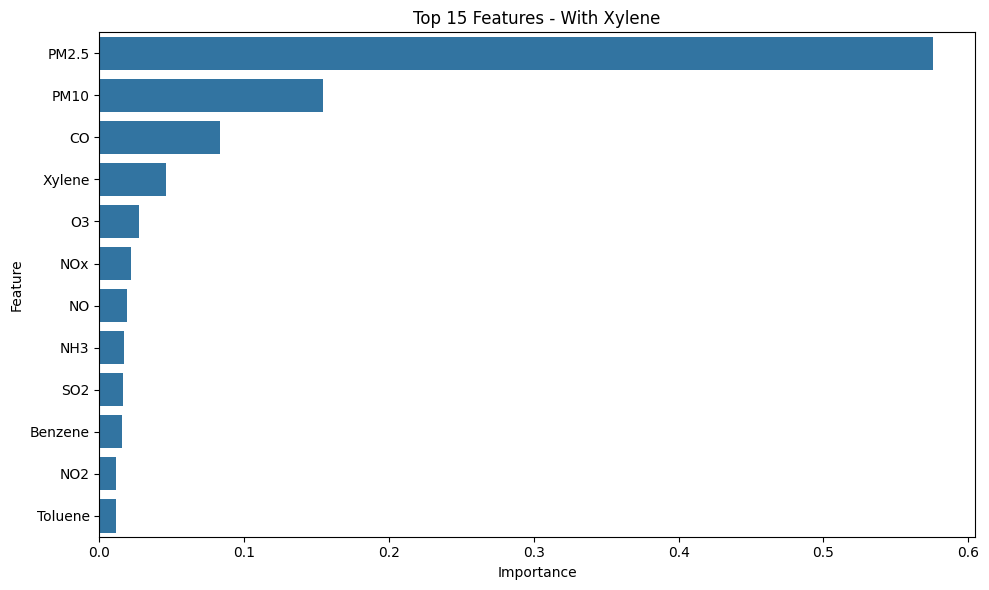

Model saved as 'best_model_With_Xylene.pkl'
Predictions saved for With Xylene


In [19]:
# TRAIN BOTH MODELS
results = []

best_model_without, result_without = train_and_evaluate(Xwo_train, Xwo_test, ywo_train, ywo_test, "Without Xylene")
results.append(result_without)

best_model_with_Xylene, result_with = train_and_evaluate(Xw_train, Xw_test, yw_train, yw_test, "With Xylene")
results.append(result_with)

In [20]:
# PERFORMANCE SUMMARY

results_df = pd.DataFrame(results)
print("\n================ FINAL PERFORMANCE SUMMARY ================\n")
print(results_df)
print("===========================================================\n")


================ FINAL PERFORMANCE SUMMARY ================

            Model        R2        MAE       RMSE
0  Without Xylene  0.911444  18.628672  32.336851
1     With Xylene  0.911978  18.481920  32.239115



In [21]:
# === SAVE MODELS AS JSON (Portable Version) ===
from xgboost import XGBRegressor

try:
    best_model_without.save_model("best_model_Without_Xylene.json")
    print("Saved: best_model_Without_Xylene.json")
except Exception as e:
    print("Could not save without-xylene model:", e)

try:
    best_model_with_Xylene.save_model("best_model_With_Xylene.json")
    print("Saved: best_model_With_Xylene.json")
except Exception as e:
    print("Could not save with-xylene model:", e)

Saved: best_model_Without_Xylene.json
Saved: best_model_With_Xylene.json
